In [1]:
device = 'cuda'

In [20]:
import logging
import os
import numpy as np
import matplotlib.pyplot
import matplotlib.pyplot as plt
import time
from typing import List, Tuple, Dict
import torch.nn.functional as F
from IPython.display import display, clear_output
import math
import torch
import argparse
from datetime import datetime
from torch.utils.data import DataLoader
from torch.nn import init
from torch import nn
import shelve
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
from logging.handlers import RotatingFileHandler
from mpl_toolkits.axes_grid1 import ImageGrid
from torchdiffeq import odeint
from torch.utils.data import Dataset
import h5py
import glob
import random
from netCDF4 import Dataset as netCDFDataset
from scipy import sparse as sp
from scipy import sparse
from scipy.sparse import spdiags
from scipy.sparse import linalg
from scipy.sparse.linalg import spsolve
from scipy.io import savemat,loadmat
import scipy.integrate as integrate
from scipy.special import iv
from functools import partial 
%matplotlib inline

In [21]:
def prepare_physics_inputs(args, batch, device):
    xt = batch["xt"].to(device).float()              # [N,4]
    xt_term = batch["xt_term"].to(device).float()    # [Nterm,4]
    x_phys = batch["x_phys"].to(device).float()      # [N,3]
    tau_phys = batch["tau_phys"].to(device).float()  # [N]
    x_term_phys = batch["x_term_phys"].to(device).float()

    b_size = 1
    state_dim = args.state_dim
    n = xt.shape[0]
    n_term = xt_term.shape[0]

    xt = xt.unsqueeze(0).unsqueeze(0).unsqueeze(-2).expand(
        b_size, 1, n, state_dim, 4
    ).detach().requires_grad_(True)

    xt_term = xt_term.unsqueeze(0).unsqueeze(0).unsqueeze(-2).expand(
        b_size, 1, n_term, state_dim, 4
    ).detach().requires_grad_(True)

    pars = torch.empty(b_size, 0, device=device)
    pars_org = pars.clone()
    par_id = torch.zeros(b_size, dtype=torch.long, device=device)

    return {
        "xt": xt,
        "xt_in": xt,
        "xt_term": xt_term,
        "x_phys": x_phys,
        "tau_phys": tau_phys,
        "x_term_phys": x_term_phys,
        "b_size": b_size,
        "t_size": 1,
        "t_inner": 1,
        "t_term": 1,
        "coord_dim": 3,
        "state_dim": state_dim,
        "spatial_shape": (n,),
        "inner_spatial_shape": (n,),
        "term_spatial_shape": (n_term,),
        "num_spatial_dims": 1,
        "pars": pars,
        "pars_org": pars_org,
        "par_id": par_id,
        "init_cond": None,
    }

In [22]:
class BasePhysicsDataset(Dataset):
    def __init__(
        self,
        param,
        size,
        t_horizon,
        nt,
        group="train",
        n_frames_train=None,
    ):
        super().__init__()

        self.param = param
        self.group = group
        self.size = size
        self.t_horizon = float(t_horizon)
        self.nt = int(nt)
        self.n_frames_train = n_frames_train if n_frames_train is not None else self.nt

        self.coord_dim = int(param["ndim"])
        self.state_dim = int(param.get("state_dim", 1))

        self.mu_lst = self.get_parameter_list()
        self.n_seq = len(self.mu_lst)

        self.coords = self.build_coords()
        self.inner_coords = self.build_inner_coords(self.coords)

    def __len__(self):
        return self.n_seq

    def get_parameter_list(self):
        raise NotImplementedError

    def build_coords(self):
        raise NotImplementedError

    def build_inner_coords(self, coords):
        raise NotImplementedError

    def get_time_grid(self):
        if self.group in ("train", "short_ts"):
            return torch.linspace(0, self.t_horizon, self.nt + 1).float()[: self.n_frames_train + 1]
        return torch.linspace(0, self.t_horizon, self.nt + 1).float()

    def get_init_func(self, mu):
        raise NotImplementedError

    def __getitem__(self, index):
        mu = self.mu_lst[index]
        t = self.get_time_grid()
        init_func = self.get_init_func(mu)
        init_cond = init_func(self.coords)

        return {
            "t": t,
            "par_id": torch.tensor(index),
            "pars": torch.tensor(mu).float(),
            "pars_org": torch.tensor(mu).float(),
            "coords": self.coords.float(),
            "inner_coords": self.inner_coords.float(),
            "init_cond": init_cond.float(),
        }

class BaseResidual(nn.Module):
    def __init__(self):
        super().__init__()

    def residual(self, model, U, xt, params, states_in=None, d_states=None, ddU=None):
        raise NotImplementedError

class BaseAnsatz:
    def __init__(self, dataset=None, device=None):
        self.dataset = dataset
        self.device = device

    def get_ic(self):
        return 0

    def get_bc(self):
        return 0

    def decoder_input(self, xt, ret_type=None):
        return xt

    def __call__(self, model, xt, U_raw, params=None, ret_type=None):
        return U_raw

class BaseProblem(nn.Module):
    branch_names = ("solution",)

    def __init__(self, args, train_dataset, aux_branch_names=()):
        super().__init__()
        self.args = args
        self.train_dataset = train_dataset
        self.aux_branch_names = tuple(aux_branch_names)
        self.branch_names = ("solution",) + self.aux_branch_names
        self.criterion = nn.MSELoss()
        self.branch_init_codes = nn.ParameterDict()

    def setup_trainable_parameters(self, device):
        self.branch_init_codes = nn.ParameterDict()

    def trainable_parameters(self):
        return list(self.branch_init_codes.parameters())

    def init_solution_latent(self, model, batch_dict):
        b_size = batch_dict["b_size"]
        device = batch_dict["xt"].device
        return torch.zeros(b_size, model.latent_width, device=device)

    def init_aux_latent(self, name, model, batch_dict):
        b_size = batch_dict["b_size"]
        device = batch_dict["xt"].device

        if name in self.branch_init_codes:
            par_id = batch_dict["par_id"]
            return self.branch_init_codes[name][par_id]

        return torch.zeros(b_size, model.latent_width, device=device)

    def init_latents(self, model, batch_dict):
        out = {"solution": self.init_solution_latent(model, batch_dict)}
        for name in self.aux_branch_names:
            out[name] = self.init_aux_latent(name, model, batch_dict)
        return out

    def decode_solution(self, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]
        return model.decoder(xt, latents_full["solution"], params=pars_org)

    def decode_aux_branch(self, name, net, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]
        return net(xt, latents_full[name], params=pars_org, ret_type="deriv")

    def decode_outputs(self, model, batch_dict, latents_full, eval_mode="train"):
        decoded = {
            "solution": self.decode_solution(model, batch_dict, latents_full, eval_mode=eval_mode)
        }
        for name, net in model.aux_decoders.items():
            if name in latents_full:
                decoded[name] = self.decode_aux_branch(name, net, model, batch_dict, latents_full, eval_mode=eval_mode)
        return decoded

    def make_zero_loss_dict(self, device):
        zero = torch.tensor(0.0, device=device)
        return {
            "loss_pinn": zero,
            "loss_ic": zero,
            "loss_bc": zero,
        }

    def compute_losses(self, model, batch_dict, decoded, latents_full, latents_inner, latents_d_inner, eval_mode="train"):
        raise NotImplementedError

    def adapt_latents(self, model, batch_dict, num_steps=100):
        return None

In [23]:
class Air3DDataset(Dataset):
    def __init__(
        self,
        num_batches,
        nx_sample,
        T=1.0,
        x1_bounds=(-1.0, 1.0),
        x2_bounds=(-1.0, 1.0),
        x3_bounds=(-math.pi, math.pi),
        n_term=None,
        tau_max=None,
        scale_to_minus1_1=True,
        scale_time_to_01=True,
    ):
        super().__init__()
        self.num_batches = int(num_batches)
        self.nx_sample = int(nx_sample)
        self.n_term = int(nx_sample if n_term is None else n_term)
        self.T = float(T)

        self.x1_bounds = tuple(x1_bounds)
        self.x2_bounds = tuple(x2_bounds)
        self.x3_bounds = tuple(x3_bounds)

        self.tau_max = float(T if tau_max is None else tau_max)
        self.scale_to_minus1_1 = bool(scale_to_minus1_1)
        self.scale_time_to_01 = bool(scale_time_to_01)

        self.coord_dim = 3
        self.state_dim = 1
        self.npars = 0

    def __len__(self):
        return self.num_batches

    def set_tau_max(self, tau_max):
        tau_max = float(tau_max)
        self.tau_max = max(0.0, min(self.T, tau_max))

    def _sample_uniform(self, n, bounds):
        lo, hi = bounds
        return lo + (hi - lo) * torch.rand(n, 1)

    def _sample_states_phys(self, n):
        x1 = self._sample_uniform(n, self.x1_bounds)
        x2 = self._sample_uniform(n, self.x2_bounds)
        x3 = self._sample_uniform(n, self.x3_bounds)
        return torch.cat([x1, x2, x3], dim=-1)

    def _scale_states(self, x_phys):
        if not self.scale_to_minus1_1:
            return x_phys
        bounds = torch.tensor(
            [self.x1_bounds, self.x2_bounds, self.x3_bounds],
            dtype=x_phys.dtype,
            device=x_phys.device,
        )
        lo = bounds[:, 0]
        hi = bounds[:, 1]
        return 2.0 * (x_phys - lo) / (hi - lo) - 1.0

    def _sample_tau_phys(self, n):
        if self.tau_max <= 0:
            return torch.zeros(n, 1)
        return self.tau_max * torch.rand(n, 1)

    def _scale_tau(self, tau_phys):
        if not self.scale_time_to_01:
            return tau_phys
        return tau_phys / self.T

    def __getitem__(self, idx):
        x_phys = self._sample_states_phys(self.nx_sample)
        x_net = self._scale_states(x_phys)

        tau_phys = self._sample_tau_phys(self.nx_sample)
        tau_net = self._scale_tau(tau_phys)

        xt = torch.cat([x_net, tau_net], dim=-1)

        x_term_phys = self._sample_states_phys(self.n_term)
        x_term_net = self._scale_states(x_term_phys)
        tau_term_phys = torch.zeros(self.n_term, 1)
        tau_term_net = self._scale_tau(tau_term_phys)

        xt_term = torch.cat([x_term_net, tau_term_net], dim=-1)

        return {
            "xt": xt.float(),
            "xt_term": xt_term.float(),
            "x_phys": x_phys.float(),
            "tau_phys": tau_phys.squeeze(-1).float(),
            "x_term_phys": x_term_phys.float(),
        }

In [24]:
class Air3DResidual(BaseResidual):
    def __init__(
        self,
        ve=0.75,
        vp=0.75,
        wmax=3.0,
        beta=0.25,
        eps=1e-12,
        T=1.0,
        x1_bounds=(-1.0, 1.0),
        x2_bounds=(-1.0, 1.0),
        x3_bounds=(-math.pi, math.pi),
        scale_to_minus1_1=False,
        scale_time_to_01=True,
    ):
        super().__init__()
        self.ve = float(ve)
        self.vp = float(vp)
        self.wmax = float(wmax)
        self.beta = float(beta)
        self.eps = float(eps)

        self.T = float(T)
        self.x1_bounds = tuple(x1_bounds)
        self.x2_bounds = tuple(x2_bounds)
        self.x3_bounds = tuple(x3_bounds)
        self.scale_to_minus1_1 = bool(scale_to_minus1_1)
        self.scale_time_to_01 = bool(scale_time_to_01)

    def target_fn(self, x_phys):
        return torch.sqrt(x_phys[..., 0] ** 2 + x_phys[..., 1] ** 2 + self.eps) - self.beta

    def _net_to_phys_x(self, x_net):
        if not self.scale_to_minus1_1:
            return x_net

        bounds = torch.tensor(
            [self.x1_bounds, self.x2_bounds, self.x3_bounds],
            dtype=x_net.dtype,
            device=x_net.device,
        )
        lo = bounds[:, 0]
        hi = bounds[:, 1]
        return 0.5 * (x_net + 1.0) * (hi - lo) + lo

    def _grad_net_to_phys(self, grad_x_net):
        if not self.scale_to_minus1_1:
            return grad_x_net

        bounds = torch.tensor(
            [self.x1_bounds, self.x2_bounds, self.x3_bounds],
            dtype=grad_x_net.dtype,
            device=grad_x_net.device,
        )
        lo = bounds[:, 0]
        hi = bounds[:, 1]
        scale = 2.0 / (hi - lo)
        return grad_x_net * scale

    def _tau_net_to_phys_derivative(self, dV_dtau_net):
        if not self.scale_time_to_01:
            return dV_dtau_net
        return dV_dtau_net / self.T

    def hamiltonian(self, x_phys, grad_x_phys):
        x1 = x_phys[..., 0]
        x2 = x_phys[..., 1]
        x3 = x_phys[..., 2]

        p1 = grad_x_phys[..., 0]
        p2 = grad_x_phys[..., 1]
        p3 = grad_x_phys[..., 2]

        return (
            p1 * (-self.ve + self.vp * torch.cos(x3))
            + p2 * (self.vp * torch.sin(x3))
            - self.wmax * torch.abs(p1 * x2 - p2 * x1 - p3)
            + self.wmax * p3
        )

    def residual(self, model, U, xt, params=None, states_in=None, d_states=None, ddU=None):
        V = U[..., 0]

        if states_in is not None and d_states is not None:
            dV_dxt, dV_dalpha = torch.autograd.grad(
                U,
                [xt, states_in],
                grad_outputs=torch.ones_like(U),
                retain_graph=True,
                create_graph=True,
            )

            grad_x_net = dV_dxt[..., 0, :3]
            V_tau_net = (dV_dalpha * d_states).sum(dim=-1)[..., 0]

            if xt.shape[-1] >= 4:
                V_tau_net = V_tau_net + dV_dxt[..., 0, 3]
        else:
            dV_dxt = torch.autograd.grad(
                U,
                xt,
                grad_outputs=torch.ones_like(U),
                retain_graph=True,
                create_graph=True,
            )[0]

            grad_x_net = dV_dxt[..., 0, :3]
            V_tau_net = dV_dxt[..., 0, 3]

        x_net = xt[..., 0, :3]
        x_phys = self._net_to_phys_x(x_net)
        grad_x_phys = self._grad_net_to_phys(grad_x_net)
        V_tau_phys = self._tau_net_to_phys_derivative(V_tau_net)

        l_x = self.target_fn(x_phys)
        H = self.hamiltonian(x_phys, grad_x_phys)

        V_t_phys = -V_tau_phys
        r = torch.minimum(V_t_phys + H, l_x - V)
        return r

In [25]:
class Air3DProblem(BaseProblem):
    branch_names = ("solution",)

    def __init__(self, args, train_dataset):
        super().__init__(args, train_dataset, aux_branch_names=())
        self.args = args
        self.train_dataset = train_dataset
        self.criterion = nn.MSELoss()

    def setup_trainable_parameters(self, device):
        self.branch_init_codes = nn.ParameterDict()

    def trainable_parameters(self):
        return []

    def init_solution_latent(self, model, batch_dict):
        b_size = batch_dict["b_size"]
        device = batch_dict["xt"].device
        return torch.zeros(b_size, model.latent_width, device=device)

    def init_latents(self, model, batch_dict):
        return {"solution": self.init_solution_latent(model, batch_dict)}

    def decode_solution(self, model, batch_dict, latents_full, eval_mode="train"):
        xt = batch_dict["xt"]
        pars_org = batch_dict["pars_org"]
        return model.decoder(xt, latents_full["solution"], params=pars_org)

    def decode_terminal(self, model, batch_dict):
        xt_term = batch_dict["xt_term"]  # [B, 1, Nterm, S, 4]
        b_size = batch_dict["b_size"]
        n_term = batch_dict["term_spatial_shape"][0]
        state_dim = batch_dict["state_dim"]
    
        latent0 = model.alpha0.view(
            1, 1, 1, state_dim, model.latent_dim
        ).expand(
            b_size, 1, n_term, state_dim, model.latent_dim
        )
    
        pars_org = batch_dict["pars_org"]
    
        return model.decoder(xt_term[..., :3], latent0, params=pars_org)
        
    def decode_outputs(self, model, batch_dict, latents_full, eval_mode="train"):
        return {
            "solution": self.decode_solution(model, batch_dict, latents_full, eval_mode=eval_mode)
        }

    def compute_losses(
        self,
        model,
        batch_dict,
        decoded,
        latents_full,
        latents_inner,
        latents_d_inner,
        eval_mode="train",
    ):
        device = decoded["solution"].device
        zero = torch.tensor(0.0, device=device)
    
        loss_dict = {
            "loss_pinn": zero,
            "loss_term": zero,
            "loss_ic": zero,
            "loss_bc": zero,
        }
    
        V_term = self.decode_terminal(model, batch_dict)  # [B,1,Nterm,S]
        x_term_phys = batch_dict["x_term_phys"].view(1, 1, -1, 3)
        l_term = model.decoder.pde.target_fn(x_term_phys).unsqueeze(-1)
    
        loss_term = self.criterion(V_term, l_term)
        loss_dict["loss_term"] = loss_term
    
        xt_in = batch_dict["xt_in"]
        pars_org = batch_dict["pars_org"]
    
        V_in = decoded["solution"]
    
        loss_pinn, _ = model.decoder.pinn_loss(
            V_in,
            xt_in,
            pars_org,
            latents_inner["solution"],
            latents_d_inner["solution"],
        )
    
        loss_dict["loss_pinn"] = loss_pinn
        return loss_dict
    
    def adapt_latents(self, model, batch_dict, num_steps=100):
        return None

In [26]:
class Swish(nn.Module):
    def __init__(self, beta=0.5):
        super().__init__()
        self.beta = nn.Parameter(torch.tensor([beta]))

    def forward(self, x):
        return (x * torch.sigmoid_(x * F.softplus(self.beta))).div_(1.1)

def create_inr_pnode(args, problem, solution_decoder, ode_func_net, aux_decoders=None, ode_solver=odeint):
    if aux_decoders is None:
        aux_decoders = nn.ModuleDict()

    model = INR_PNODE(
        args=args,
        ode_func_net=ode_func_net,
        solution_decoder=solution_decoder,
        problem=problem,
        ode_solver=ode_solver,
        aux_decoders=aux_decoders,
    )

    lr = args.lr
    optimizers = {
        "optim_solution_decoder": torch.optim.Adam(model.solution_decoder.parameters(), lr=lr),
        "optim_ode_func_net": torch.optim.Adam(model.ode_func_net.parameters(), lr=lr / 10),
        "optim_alpha0": torch.optim.Adam([model.alpha0], lr=lr)
    }

    aux_params = [p for m in model.aux_decoders.values() for p in m.parameters()]
    if len(aux_params) > 0:
        optimizers["optim_aux_decoders"] = torch.optim.Adam(aux_params, lr=lr)

    if hasattr(problem, "trainable_parameters"):
        extra_params = list(problem.trainable_parameters())
        if len(extra_params) > 0:
            optimizers["optim_problem"] = torch.optim.Adam(extra_params, lr=lr / 10)

    return model, optimizers


class LossManager(nn.Module):
    def __init__(self, problem, pi_loss=True, loss_weights=None):
        super().__init__()
        self.problem = problem

        if loss_weights is not None:
            self.loss_weights = loss_weights
        else:
            self.loss_weights = {
                "term": 1.0,
                "pinn": 1.0,
                "ic": 0.0,
                "bc": 0.0,
            }

    def _to_tensor_scalar(self, v, device):
        if isinstance(v, torch.Tensor):
            return v.mean()
        return torch.tensor(float(v), device=device)

    def compute_all_losses(self, batch, model_output, loss_dict):
        zero = torch.tensor(0.0, device=model_output.device)
        results = dict(loss_dict) if loss_dict is not None else {}

        loss_train = zero
        for name, weight in self.loss_weights.items():
            key = name if name.startswith("loss_") else f"loss_{name}"
            value = results.get(key, zero)
            value = self._to_tensor_scalar(value, model_output.device)
            loss_train = loss_train + weight * value

        results["loss_train"] = loss_train
        results["params"] = batch.get("pars_org", None)
        return results


class MLP(nn.Module):
    def __init__(self, code_dim, hidden_dim, out_dim=None):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(code_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, code_dim if out_dim is None else out_dim)
        )

    def forward(self, x):
        return self.model(x)


class DerivativePNODE(nn.Module):
    def __init__(self, state_dim, latent_dim, hidden_dim, num_params=0, auxilliary_dim=1):
        super().__init__()
        self.latent_dim = latent_dim
        self.input_dim = latent_dim * state_dim * auxilliary_dim
        self.model = MLP(self.input_dim + 1, hidden_dim, out_dim=self.input_dim)

    def forward(self, t, u):
        if not torch.is_tensor(t):
            t = torch.tensor(t, dtype=u.dtype, device=u.device)
        if t.ndim == 0:
            t_feat = t.expand(u.shape[:-1] + (1,))
        else:
            t_feat = t[..., None].expand(u.shape[:-1] + (1,))
        inp = torch.cat([u, t_feat], dim=-1)
        return self.model(inp)


class Derivative(nn.Module):
    def __init__(self, state_dim, latent_dim, hidden_dim):
        super().__init__()
        input_dim = state_dim * latent_dim
        self.model = MLP(input_dim, hidden_dim)

    def forward(self, t, u):
        return self.model(u)


class Decoder(nn.Module):
    def __init__(self, state_dim, hidden_dim, latent_dim, coordinate_dim, out_dim, num_layers, input_scale=64):
        super().__init__()
        self.state_dim = state_dim
        self.hidden_dim = hidden_dim
        self.latent_dim = latent_dim
        self.coordinate_dim = coordinate_dim
        self.out_dim = out_dim
        self.model = FourierNet(self.coordinate_dim, self.hidden_dim, self.latent_dim, self.out_dim, num_layers, input_scale=input_scale)

    def forward(self, x, codes=None):
        if codes is None:
            return self.model(x)
        return self.model(x, codes)

class MFNBase(nn.Module):
    def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers):
        super().__init__()
        self.conditioning = nn.ModuleList(
            [AdditiveConditioning(in_dim, code_dim, hidden_dim)] +
            [AdditiveConditioning(hidden_dim, code_dim, hidden_dim) for _ in range(num_layers)]
        )
        self.conditioning_out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x, code):
        out = self.filters[0](x) * self.conditioning[0](x * 0., code)
        for i in range(1, len(self.filters)):
            out = self.filters[i](x) * self.conditioning[i](out, code)

        out = self.conditioning_out(out)
        if out.shape[-1] == 1:
            out = out.squeeze(-1)
        return out, x

class FourierLayer(nn.Module):
    def __init__(self, in_features, out_features, weight_scale):
        super().__init__()
        self.weight = nn.parameter.Parameter(torch.empty((out_features, in_features)))
        self.weight_scale = weight_scale
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))

    def forward(self, x):
        return torch.cat([
            torch.sin(F.linear(x, self.weight * self.weight_scale)),
            torch.cos(F.linear(x, self.weight * self.weight_scale))
        ], dim=-1)


class FourierNet(MFNBase):
    def __init__(self, in_dim, hidden_dim, code_dim, out_dim, num_layers=3, input_scale=256.0):
        super().__init__(in_dim, hidden_dim, code_dim, out_dim, num_layers)
        self.filters = nn.ModuleList(
            [FourierLayer(in_dim, hidden_dim // 2, input_scale / np.sqrt(num_layers + 1)) for _ in range(num_layers + 1)]
        )

    def get_filters_weight(self):
        weights = []
        for f in self.filters:
            weights.append(f.weight)
        return torch.cat(weights)


class AdditiveConditioning(nn.Module):
    def __init__(self, x, code, out):
        super().__init__()
        self.x = x
        self.code = code
        self.out = out
        self.A = nn.parameter.Parameter(torch.empty(self.out, self.code))
        self.B = nn.parameter.Parameter(torch.empty(self.out, self.x))
        self.bias = nn.parameter.Parameter(torch.empty(self.out))
        self.reset_parameters()

    def reset_parameters(self):
        bound = 1 / math.sqrt(self.x)
        nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))
        nn.init.kaiming_uniform_(self.B, a=math.sqrt(5))
        nn.init.uniform_(self.bias, -bound, bound)

    def forward(self, x, code):
        code_transform = torch.einsum('...j,oj->...o', code, self.A)
        x_transform = torch.einsum('...i,oi->...o', x, self.B)
        return code_transform + x_transform + self.bias


class PINN(nn.Module):
    def __init__(self, decoder, pde, out_dim, ic_fn=None, ansatz=None):
        super().__init__()
        self.decoder = decoder
        self.pde = pde
        self.out_dim = out_dim
        self.ic_fn = ic_fn
        self.ansatz = ansatz
        self.loss = nn.MSELoss()
        self.loss_l1 = nn.L1Loss()

    def grad_wrt_coords(self, U, xt):
        return torch.autograd.grad(
            U, xt,
            grad_outputs=torch.ones_like(U),
            retain_graph=True,
            create_graph=True
        )[0]

    def pinn_loss(self, U, xt, params, states_in=None, d_states=None, ddU=None, truncate=None):
        residual = self.pde.residual(
            model=self,
            U=U,
            xt=xt,
            params=params,
            states_in=states_in,
            d_states=d_states,
            ddU=ddU
        )
        loss_pinn = torch.mean(torch.abs(residual))
        if truncate is None:
            loss_pinn_trunc = loss_pinn
        else:
            loss_pinn_trunc = torch.mean(residual[:, :truncate] ** 2)
        return loss_pinn, loss_pinn_trunc

    def get_ic(self):
        if self.ansatz is not None and hasattr(self.ansatz, "get_ic"):
            return self.ansatz.get_ic()
        return 0

    def get_bc(self):
        if self.ansatz is not None and hasattr(self.ansatz, "get_bc"):
            return self.ansatz.get_bc()
        return 0

    def forward(self, xt, latents, params=None, ret_type=None):
        if self.ansatz is not None and hasattr(self.ansatz, "decoder_input"):
            decoder_xt = self.ansatz.decoder_input(xt, ret_type=ret_type)
        else:
            decoder_xt = xt[..., :self.decoder.coordinate_dim]

        U = self.decoder(decoder_xt, latents)[0]

        if self.ansatz is None or ret_type == "deriv":
            return U

        return self.ansatz(model=self, xt=xt, U_raw=U, params=params, ret_type=ret_type)


class INR_PNODE(nn.Module):
    def __init__(self, args, ode_func_net, solution_decoder, problem, ode_solver=odeint, aux_decoders=None):
        super().__init__()
        self.args = args
        self.device = args.device if hasattr(args, "device") else None

        self.ode_func_net = ode_func_net
        self.solution_decoder = solution_decoder
        self.decoder = solution_decoder

        self.problem = problem
        self.ode_solver = ode_solver
        self.aux_decoders = aux_decoders if aux_decoders is not None else nn.ModuleDict()

        self.loss_manager = LossManager(problem, pi_loss=args.pi_loss)
        self.criterion = nn.MSELoss()


        self.state_dim = args.state_dim
        self.latent_dim = args.code_dim
        self.num_params = args.npars
        self.branch_names = tuple(problem.branch_names)

        self.alpha0 = nn.Parameter(torch.zeros(1, self.state_dim*self.latent_dim))
        
        if len(self.branch_names) == 0 or self.branch_names[0] != "solution":
            raise ValueError("problem.branch_names must start with 'solution'")

        missing_aux = [name for name in self.branch_names[1:] if name not in self.aux_decoders]
        if len(missing_aux) > 0:
            raise ValueError(f"Missing aux decoders for branches: {missing_aux}")

    @property
    def latent_width(self):
        return self.state_dim * self.latent_dim

    def latent_and_dlatent_at_tau(self, tau_query):
        device = tau_query.device
        tau_query = tau_query.reshape(-1)
    
        tau_unique, inverse = torch.unique(tau_query, sorted=True, return_inverse=True)
        # make sure 0 is included exactly once
        if tau_unique.numel() == 0 or tau_unique[0].item() > 0.0:
            t_eval = torch.cat([torch.zeros(1, device=device, dtype=tau_unique.dtype), tau_unique], dim=0)
            has_prepended_zero = True
        else:
            t_eval = tau_unique
            has_prepended_zero = False
    
        y0 = self.alpha0  # [1, latent_width]
    
        latent_traj = self.ode_solver(
            self.ode_func_net,
            y0,
            t_eval,
            rtol=self.args.rtol,
            atol=self.args.atol,
            method=self.args.method,
        )[:, 0, :]  # [K, latent_width]
    
        dlatent_traj = torch.stack(
            [self.ode_func_net(t_eval[i], latent_traj[i:i+1]).squeeze(0) for i in range(t_eval.shape[0])],
            dim=0,
        )  # [K, latent_width]
    
        if has_prepended_zero:
            latent_unique = latent_traj[1:]
            dlatent_unique = dlatent_traj[1:]
        else:
            latent_unique = latent_traj
            dlatent_unique = dlatent_traj
    
        latent = latent_unique[inverse]     # [N, latent_width]
        dlatent = dlatent_unique[inverse]   # [N, latent_width]
    
        return latent, dlatent

    def _prepare_batch(self, batch):
        return prepare_physics_inputs(self.args, batch, self.device)

    def grad_wrt_coords(self, Y, coords):
        return torch.autograd.grad(
            Y, coords,
            grad_outputs=torch.ones_like(Y),
            retain_graph=True,
            create_graph=True
        )[0]

    def concat_latents(self, latent_dict):
        return torch.cat([latent_dict[name] for name in self.branch_names], dim=-1)

    def unpack_latents(self, flattened_latents):
        out = {}
        start = 0
        for name in self.branch_names:
            end = start + self.latent_width
            out[name] = flattened_latents[..., start:end]
            start = end
        return out

    def latent_at_tau(self, tau_query):
        device = tau_query.device
        N = tau_query.shape[0]
    
        tau_sorted, perm = torch.sort(tau_query)
        inv_perm = torch.empty_like(perm)
        inv_perm[perm] = torch.arange(N, device=device)
    
        if tau_sorted[0].item() > 0.0:
            t_eval = torch.cat([torch.zeros(1, device=device), tau_sorted], dim=0)
            prepend_zero = True
        else:
            t_eval = tau_sorted
            prepend_zero = False
    
        y0 = self.alpha0  # [1, latent_width]
    
        latent_traj = self.ode_solver(
            self.ode_func_net,
            y0,
            t_eval,
            rtol=getattr(self.args, "rtol", 1e-7),
            atol=getattr(self.args, "atol", 1e-9),
            method=self.args.method,
        )  # [K,1,D]
    
        latent_traj = latent_traj[:, 0, :]  # [K,D]
    
        if prepend_zero:
            latent_sorted = latent_traj[1:]
        else:
            latent_sorted = latent_traj
    
        latent_unsorted = latent_sorted[inv_perm]
        return latent_unsorted

    def decode_at_xt(self, xt, tau_phys):
        B, T, N, S, C = xt.shape
        latent, dlatent = self.latent_and_dlatent_at_tau(tau_phys)
    
        latent = latent.view(1, 1, N, 1, self.latent_dim).requires_grad_(True)
        dlatent = dlatent.view(1, 1, N, 1, self.latent_dim)
    
        x_in = xt[..., :3]
        out = self.decoder(x_in, latent)
        return out, latent, dlatent
    
    def expand_latents(self, latent_dict, batch_dict, inner=False, requires_grad=False):
        batch_size = batch_dict["b_size"]
        time_size = batch_dict["t_size"]
        spatial_shape = batch_dict["inner_spatial_shape"] if inner else batch_dict["spatial_shape"]
        num_spatial_dims = len(spatial_shape)

        expanded = {}
        for name, latent in latent_dict.items():
            latent = latent[:, :time_size]
            latent = latent.view(
                batch_size,
                time_size,
                *([1] * num_spatial_dims),
                self.state_dim,
                self.latent_dim,
            )
            latent = latent.expand(
                batch_size,
                time_size,
                *spatial_shape,
                self.state_dim,
                self.latent_dim,
            )
            if requires_grad:
                latent = latent.requires_grad_(True)
            expanded[name] = latent
        return expanded

    def solve_latent_trajectory(self, batch_dict, init_latents):
        time = batch_dict["t"]
        params = batch_dict["pars"]
        rtol = getattr(self.args, "rtol", 1e-7)
        atol = getattr(self.args, "atol", 1e-9)
        method = self.args.method

        y0_latent = self.concat_latents(init_latents)
        y0_augmented = torch.cat([y0_latent, params], dim=-1)

        if hasattr(self.ode_func_net, "set_params"):
            self.ode_func_net.set_params(params)

        latent_augmented = self.ode_solver(
            self.ode_func_net,
            y0_augmented,
            time,
            rtol=rtol,
            atol=atol,
            method=method
        )

        if self.num_params > 0:
            flat_latents = latent_augmented[..., :-self.num_params].permute(1, 0, 2).contiguous()
        else:
            flat_latents = latent_augmented.permute(1, 0, 2).contiguous()
        latent_trajectory = self.unpack_latents(flat_latents)
        
        ode_rhs = self.ode_func_net(time, latent_augmented)
        if self.num_params > 0:
            flat_d_latents = ode_rhs[..., :-self.num_params].permute(1, 0, 2).contiguous()
        else:
            flat_d_latents = ode_rhs.permute(1, 0, 2).contiguous()
        latent_d_trajectory = self.unpack_latents(flat_d_latents)

        return latent_trajectory, latent_d_trajectory

    def predict(self, batch, mode="predict"):
        batch_dict = self._prepare_batch(batch)
        V, _, _ = self.decode_at_xt(batch_dict["xt"], batch_dict["tau_phys"])
        return V

    def data_reconstruction(self, batch, eval_mode="train", batch_dict=None):
        if batch_dict is None:
            batch_dict = self._prepare_batch(batch)
    
        V_in, latent_in, dlatent_in = self.decode_at_xt(
            batch_dict["xt_in"],
            batch_dict["tau_phys"],
        )
    
        decoded = {"solution": V_in}
        latents_inner = {"solution": latent_in}
        latents_d_inner = {"solution": dlatent_in}
        latents_full = {"solution": latent_in}
    
        loss_dict = self.problem.compute_losses(
            model=self,
            batch_dict=batch_dict,
            decoded=decoded,
            latents_full=latents_full,
            latents_inner=latents_inner,
            latents_d_inner=latents_d_inner,
            eval_mode=eval_mode,
        )
    
        return decoded["solution"], loss_dict

    def eval_reconstruction(self, batch, n_steps=100):
        self.eval()
        batch_dict = self._prepare_batch(batch)
        with torch.no_grad():
            V, _, _ = self.decode_at_xt(batch_dict["xt"], batch_dict["tau_phys"])
        self.train()
        return V

    def compute_all_losses(self, batch, mode="train"):
        batch_dict = self._prepare_batch(batch)

        if mode == "visualization":
            model_output, _ = self.data_reconstruction(batch, eval_mode=mode, batch_dict=batch_dict)
            return model_output.detach().cpu().numpy()

        model_output, loss_dict = self.data_reconstruction(batch, eval_mode=mode, batch_dict=batch_dict)
        return self.loss_manager.compute_all_losses(batch_dict, model_output, loss_dict)

In [27]:
args = argparse.Namespace(
    dName="air3d",
    checkpoint=None,
    meshType="coarse",
    setType=0,
    gpu=1,
    pi_loss=True,
    test_idx=None,
    mode="pnode",
    ic=1,
    bc=1,
    viz=1,
    input_scale=16.0,
    lr=1e-4,
    initType="Cecchi",
    cuda=None,
)

args.device = device

# problem dimensions
args.state_dim = 1
args.coord_dim = 3
args.code_dim = 64
args.latent_dim = args.code_dim
args.npars = 0
args.num_params = 0

# model size
args.hidden_c = 128          # latent ODE net width
args.hidden_c_enc = 128      # decoder width
args.n_layers = 3
args.input_scale = 16.0

# ODE solver
args.method = "dopri5"
args.rtol = 1e-7
args.atol = 1e-9

# Air3D params
args.T = 1.0
args.ve = 0.75
args.vp = 0.75
args.wmax = 3.0
args.beta = 0.25

# domain
args.x1_bounds = (-1.0, 1.0)
args.x2_bounds = (-1.0, 1.0)
args.x3_bounds = (-math.pi, math.pi)

# training batch sampling
args.num_batches = 1000
args.nx_sample = 4096
args.n_term = 4096

# scaling
args.scale_to_minus1_1 = False
args.scale_time_to_01 = True


dataset_tr = Air3DDataset(
    num_batches=args.num_batches,
    nx_sample=args.nx_sample,
    T=args.T,
    x1_bounds=args.x1_bounds,
    x2_bounds=args.x2_bounds,
    x3_bounds=args.x3_bounds,
    n_term=args.n_term,
    tau_max=0.0,  # start with terminal pretraining
    scale_to_minus1_1=args.scale_to_minus1_1,
    scale_time_to_01=args.scale_time_to_01,
)

dataloader_tr = DataLoader(
    dataset_tr,
    batch_size=None,
    shuffle=False,
)

args.dataset_dict = {"train": dataset_tr}
args.dataloader_dict = {"train": dataloader_tr}
args.setName = "train"

args.params_dict = {
    "train": {
        "t_horizon": args.T,
        "n_seq": 1,
    }
}

solution_decoder = PINN(
    decoder=Decoder(
        state_dim=args.state_dim,
        hidden_dim=args.hidden_c_enc,
        latent_dim=args.code_dim,
        coordinate_dim=3,   # decoder sees x only
        out_dim=1,          # scalar value V
        num_layers=args.n_layers,
        input_scale=args.input_scale,
    ),
    pde=Air3DResidual(
        ve=args.ve,
        vp=args.vp,
        wmax=args.wmax,
        beta=args.beta,
        T=args.T,
        x1_bounds=args.x1_bounds,
        x2_bounds=args.x2_bounds,
        x3_bounds=args.x3_bounds,
        scale_to_minus1_1=args.scale_to_minus1_1,
        scale_time_to_01=args.scale_time_to_01,
    ),
    out_dim=1,
    ansatz=None,
)

problem = Air3DProblem(args, dataset_tr)
problem.setup_trainable_parameters(device)

ode_func_net = DerivativePNODE(
    state_dim=args.state_dim,
    latent_dim=args.code_dim,
    hidden_dim=args.hidden_c,
    num_params=0,
    auxilliary_dim=1,
)

aux_decoders = nn.ModuleDict()

model, optimizers = create_inr_pnode(
    args=args,
    problem=problem,
    solution_decoder=solution_decoder,
    ode_func_net=ode_func_net,
    aux_decoders=aux_decoders,
    ode_solver=odeint,
)

model = model.to(device)
model.decoder = model.decoder.to(device)
model.ode_func_net = model.ode_func_net.to(device)

print(f"Decoder params:  {sum(p.numel() for p in model.decoder.parameters()):,}")
print(f"Dynamics params: {sum(p.numel() for p in model.ode_func_net.parameters()):,}")

Decoder params:  83,713
Dynamics params: 49,731


In [28]:
def eval_air3d_value_on_slice(
    model,
    device,
    tau,
    x3_value,
    x1_bounds,
    x2_bounds,
    nx=101,
    chunk_size=2048,
):
    model.eval()

    x1 = torch.linspace(x1_bounds[0], x1_bounds[1], nx, device=device)
    x2 = torch.linspace(x2_bounds[0], x2_bounds[1], nx, device=device)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")

    X3 = torch.full_like(X1, float(x3_value))
    TAU = torch.full_like(X1, float(tau))

    pts = torch.stack([X1, X2, X3, TAU], dim=-1).reshape(-1, 4)
    npts = pts.shape[0]

    with torch.no_grad():
        latent0 = model.problem.init_latents(
            model,
            {"b_size": 1, "xt": torch.zeros(1, 1, 1, model.state_dim, 4, device=device)},
        )["solution"]

        if tau <= 0.0:
            latent_t_flat = latent0
        else:
            time = torch.tensor([0.0, float(tau)], device=device)

            if hasattr(model.ode_func_net, "set_params"):
                model.ode_func_net.set_params(torch.empty(1, 0, device=device))

            latent_aug = model.ode_solver(
                model.ode_func_net,
                latent0,
                time,
                rtol=model.args.rtol,
                atol=model.args.atol,
                method=model.args.method,
            )
            latent_t_flat = latent_aug[-1]

        values = []
        for start in range(0, npts, chunk_size):
            end = min(start + chunk_size, npts)
            pts_chunk = pts[start:end]

            xt = pts_chunk.unsqueeze(0).unsqueeze(0).unsqueeze(3)  # [1,1,M,1,4]

            latent_t = latent_t_flat.view(
                1, 1, 1, model.state_dim, model.latent_dim
            ).expand(
                1, 1, pts_chunk.shape[0], model.state_dim, model.latent_dim
            )

            V = model.decoder(xt, latent_t, params=torch.empty(1, 0, device=device))
            V = V.squeeze(0).squeeze(0).squeeze(-1)
            values.append(V.cpu())

    V = torch.cat(values, dim=0).reshape(nx, nx).numpy()

    return X1.cpu().numpy(), X2.cpu().numpy(), V

def plot_air3d(
    model,
    device,
    taus=(0.0, 0.5, 1.0),
    x3_value=math.pi / 2,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    nx=101,
    chunk_size=2048,
    show_target_at_tau0=True,
    mask_plot=False,
):

    fig, axes = plt.subplots(1, len(taus), figsize=(5 * len(taus), 4))
    if len(taus) == 1:
        axes = [axes]

    beta = model.decoder.pde.beta
    th = np.linspace(0, 2 * np.pi, 400)

    for ax, tau in zip(axes, taus):
        X1, X2, V = eval_air3d_value_on_slice(
            model=model,
            device=device,
            tau=tau,
            x3_value=x3_value,
            x1_bounds=x1_bounds,
            x2_bounds=x2_bounds,
            nx=nx,
            chunk_size=chunk_size,
        )

        if not mask_plot:
            im = ax.contourf(X1, X2, V.T, levels=60, cmap="viridis")
            ax.contour(X1, X2, V.T, levels=[0.0], colors="red", linewidths=2)
        else:
            mask = (V <= 0).astype(float)
            ax.contourf(X1, X2, mask.T, levels=[-0.1, 0.5, 1.1], alpha=0.9)
            ax.contour(X1, X2, V.T, levels=[0.0], colors="red", linewidths=2)

        if show_target_at_tau0 and abs(tau) < 1e-12:
            ax.plot(beta * np.cos(th), beta * np.sin(th), "w--" if not mask_plot else "k--", linewidth=1.5)

        ax.set_title(fr"$x_3={x3_value:.2f},\ \tau={tau:.2f}$")
        ax.set_xlabel(r"$x_1$")
        ax.set_ylabel(r"$x_2$")

    if not mask_plot:
        fig.colorbar(im, ax=axes, shrink=0.9)

    plt.tight_layout()
    plt.show()

def plot_air3d_slice(
    model,
    device,
    tau=0.0,
    x3_value=math.pi / 2,
    x1_bounds=(-1.0, 1.0),
    x2_bounds=(-1.0, 1.0),
    nx=151,
    chunk_size=4096,
    title=None,
    show_target=True,
):
    model.eval()

    x1 = torch.linspace(x1_bounds[0], x1_bounds[1], nx, device=device)
    x2 = torch.linspace(x2_bounds[0], x2_bounds[1], nx, device=device)
    X1, X2 = torch.meshgrid(x1, x2, indexing="xy")

    X3 = torch.full_like(X1, float(x3_value))
    TAU = torch.full_like(X1, float(tau))

    # [Npts, 4]
    pts = torch.stack([X1, X2, X3, TAU], dim=-1).reshape(-1, 4)
    npts = pts.shape[0]

    with torch.no_grad():
        # Initial latent at tau = 0
        latent0 = model.problem.init_latents(
            model,
            {
                "b_size": 1,
                "xt": torch.zeros(1, 1, 1, model.state_dim, 4, device=device),
            },
        )["solution"]  # [1, latent_width]

        # Solve latent trajectory from 0 to tau
        if tau <= 0.0:
            latent_t_flat = latent0
        else:
            time = torch.tensor([0.0, float(tau)], device=device)
            y0 = latent0

            if hasattr(model.ode_func_net, "set_params"):
                model.ode_func_net.set_params(torch.empty(1, 0, device=device))

            latent_aug = model.ode_solver(
                model.ode_func_net,
                y0,
                time,
                rtol=model.args.rtol,
                atol=model.args.atol,
                method=model.args.method,
            )
            latent_t_flat = latent_aug[-1]  # [1, latent_width]

        values = []

        for start in range(0, npts, chunk_size):
            end = min(start + chunk_size, npts)
            pts_chunk = pts[start:end]  # [M, 4]

            # Correct shape: [B, Nt, Nx, state_dim, 4]
            xt = pts_chunk.unsqueeze(0).unsqueeze(0).unsqueeze(3)  # [1, 1, M, 1, 4]

            latent_t = latent_t_flat.view(
                1, 1, 1, model.state_dim, model.latent_dim
            ).expand(
                1, 1, pts_chunk.shape[0], model.state_dim, model.latent_dim
            )

            V = model.decoder(xt, latent_t, params=torch.empty(1, 0, device=device))
            V = V.squeeze(0).squeeze(0).squeeze(-1)  # [M]
            values.append(V.cpu())

    V = torch.cat(values, dim=0).reshape(nx, nx).numpy()

    X1_np = X1.cpu().numpy()
    X2_np = X2.cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    im = axes[0].contourf(X1_np, X2_np, V.T, levels=60, cmap="viridis")
    plt.colorbar(im, ax=axes[0])
    axes[0].contour(X1_np, X2_np, V.T, levels=[0.0], colors="red", linewidths=2)
    axes[0].set_xlabel(r"$x_1$")
    axes[0].set_ylabel(r"$x_2$")
    axes[0].set_title(title or fr"Value slice at $x_3=\pi/2$, $\tau={tau:.2f}$")

    if show_target:
        beta = model.decoder.pde.beta
        th = np.linspace(0, 2 * np.pi, 400)
        axes[0].plot(beta * np.cos(th), beta * np.sin(th), "w--", linewidth=1.5)

    mask = (V <= 0).astype(float)
    axes[1].contourf(X1_np, X2_np, mask.T, levels=[-0.1, 0.5, 1.1], alpha=0.8)
    axes[1].contour(X1_np, X2_np, V.T, levels=[0.0], colors="red", linewidths=2)
    axes[1].set_xlabel(r"$x_1$")
    axes[1].set_ylabel(r"$x_2$")
    axes[1].set_title(r"BRT slice ($V \leq 0$)")

    if show_target:
        beta = model.decoder.pde.beta
        th = np.linspace(0, 2 * np.pi, 400)
        axes[1].plot(beta * np.cos(th), beta * np.sin(th), "k--", linewidth=1.5)

    plt.tight_layout()
    plt.show()

    model.train()

In [29]:
dataset_tr.set_tau_max(0.0)
model.loss_manager.loss_weights = {"term": 1.0, "pinn": 0.0, "ic": 0.0, "bc": 0.0}

In [30]:
for step, batch in enumerate(dataloader_tr):
    if step >= 1000:
        break

    for opt in optimizers.values():
        opt.zero_grad()

    results = model.compute_all_losses(batch, mode="train")
    results["loss_train"].backward()

    torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
    torch.nn.utils.clip_grad_norm_(model.ode_func_net.parameters(), max_norm=1.0)

    if "optim_problem" in optimizers:
        problem_params = problem.trainable_parameters()
        if len(problem_params) > 0:
            torch.nn.utils.clip_grad_norm_(problem_params, max_norm=1.0)

    for opt in optimizers.values():
        opt.step()

    if step % 50 == 0:
        print(step, results["loss_term"].item(), results["loss_train"].item())

0 0.27412253618240356 0.27412253618240356
50 0.2551853060722351 0.2551853060722351
100 0.2185603827238083 0.2185603827238083
150 0.16049689054489136 0.16049689054489136
200 0.0765153169631958 0.0765153169631958
250 0.021046526730060577 0.021046526730060577
300 0.009168047457933426 0.009168047457933426
350 0.005440759006887674 0.005440759006887674
400 0.0036314707249403 0.0036314707249403
450 0.002646918408572674 0.002646918408572674
500 0.002056767465546727 0.002056767465546727
550 0.0015511781675741076 0.0015511781675741076
600 0.0012474583927541971 0.0012474583927541971
650 0.001026645884849131 0.001026645884849131
700 0.0008331096032634377 0.0008331096032634377
750 0.0007233897922560573 0.0007233897922560573
800 0.0006143396021798253 0.0006143396021798253
850 0.0005317552713677287 0.0005317552713677287
900 0.0005040453397668898 0.0005040453397668898
950 0.0004572625912260264 0.0004572625912260264


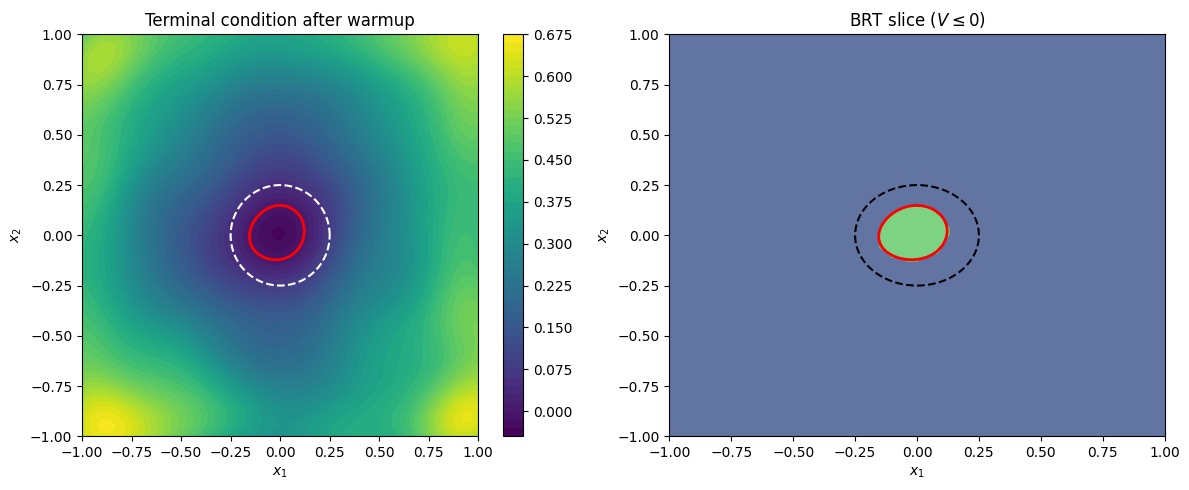

In [31]:
plot_air3d_slice(model, device=device, tau=0.0, x3_value=math.pi / 2, x1_bounds=args.x1_bounds, x2_bounds=args.x2_bounds, nx=101, chunk_size=2048, title="Terminal condition after warmup")

In [32]:
model.loss_manager.loss_weights = {
    "term": 1.0,
    "pinn": 1.0,
    "ic": 0.0,
    "bc": 0.0,
}
dataset_tr.set_tau_max(0.05)


Training with tau_max = 0.05
step    0 | loss=6.565e-01 | term=3.845e-04 | pinn=6.561e-01
step   50 | loss=1.563e-01 | term=3.068e-02 | pinn=1.256e-01
step  100 | loss=1.094e-01 | term=2.691e-02 | pinn=8.251e-02
step  150 | loss=8.830e-02 | term=2.314e-02 | pinn=6.516e-02
step  200 | loss=7.475e-02 | term=2.051e-02 | pinn=5.424e-02
step  250 | loss=6.398e-02 | term=1.664e-02 | pinn=4.733e-02
step  300 | loss=5.348e-02 | term=1.405e-02 | pinn=3.943e-02
step  350 | loss=4.685e-02 | term=1.217e-02 | pinn=3.469e-02


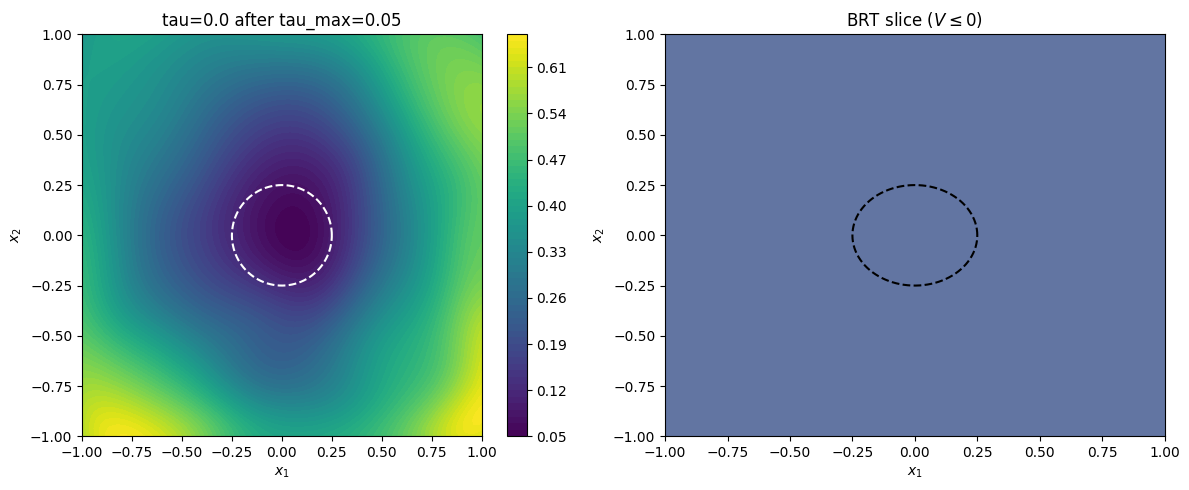

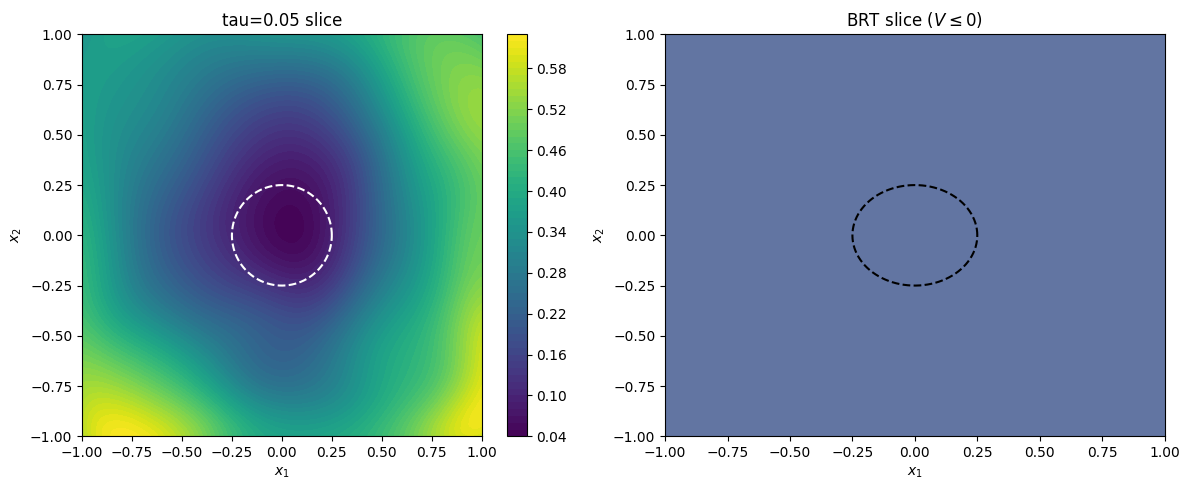


Training with tau_max = 0.10
step    0 | loss=4.330e-02 | term=1.046e-02 | pinn=3.284e-02
step   50 | loss=3.702e-02 | term=7.555e-03 | pinn=2.947e-02
step  100 | loss=3.391e-02 | term=6.700e-03 | pinn=2.721e-02
step  150 | loss=3.038e-02 | term=5.463e-03 | pinn=2.492e-02
step  200 | loss=2.876e-02 | term=5.337e-03 | pinn=2.342e-02
step  250 | loss=2.700e-02 | term=4.176e-03 | pinn=2.282e-02
step  300 | loss=2.623e-02 | term=4.138e-03 | pinn=2.209e-02
step  350 | loss=2.370e-02 | term=3.155e-03 | pinn=2.054e-02


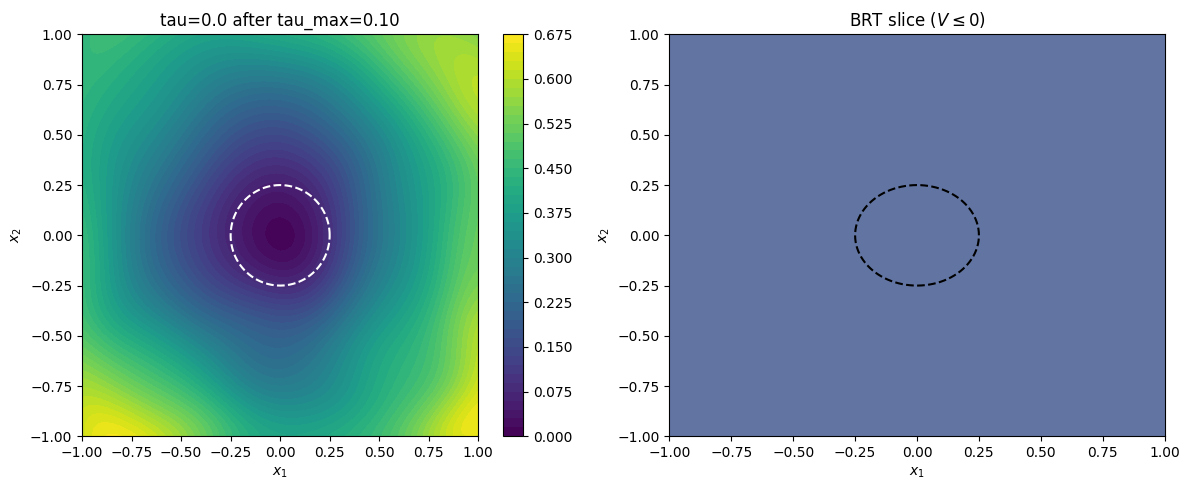

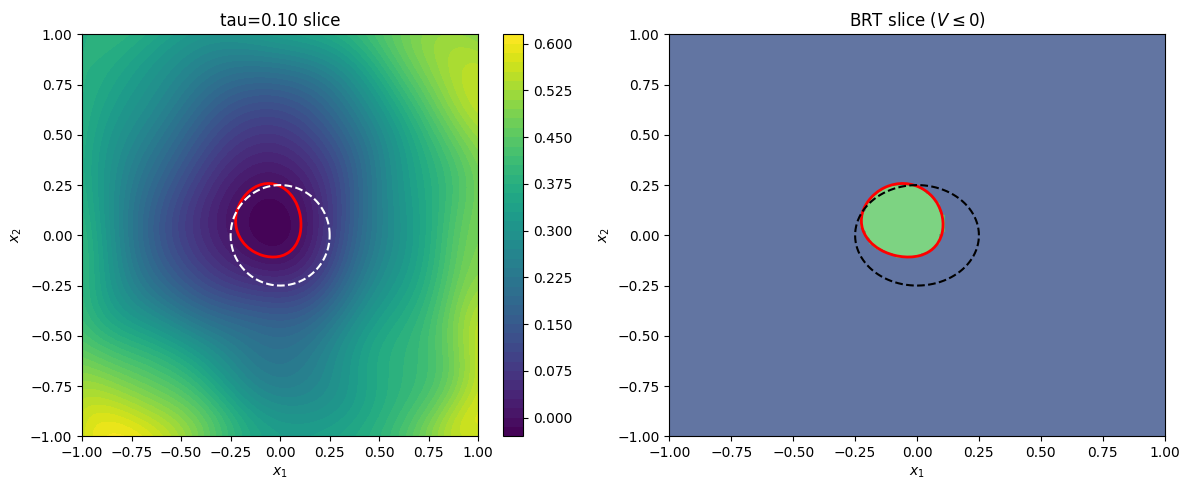


Training with tau_max = 0.20
step    0 | loss=3.839e-02 | term=2.876e-03 | pinn=3.551e-02
step   50 | loss=3.144e-02 | term=3.371e-03 | pinn=2.807e-02
step  100 | loss=2.992e-02 | term=3.251e-03 | pinn=2.667e-02
step  150 | loss=3.010e-02 | term=3.305e-03 | pinn=2.680e-02
step  200 | loss=2.852e-02 | term=2.911e-03 | pinn=2.560e-02
step  250 | loss=2.809e-02 | term=2.784e-03 | pinn=2.531e-02
step  300 | loss=2.656e-02 | term=2.858e-03 | pinn=2.371e-02
step  350 | loss=2.609e-02 | term=2.524e-03 | pinn=2.357e-02


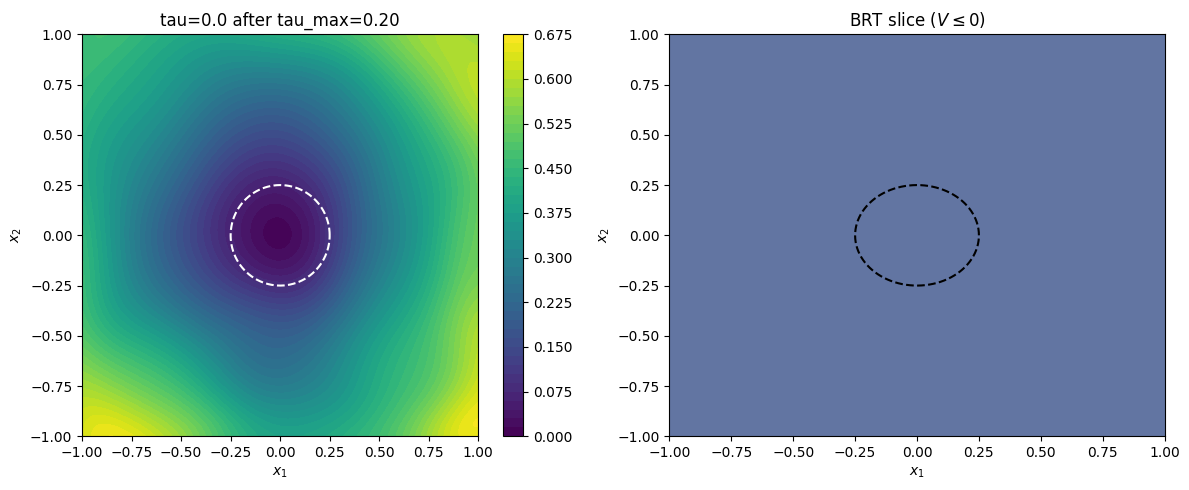

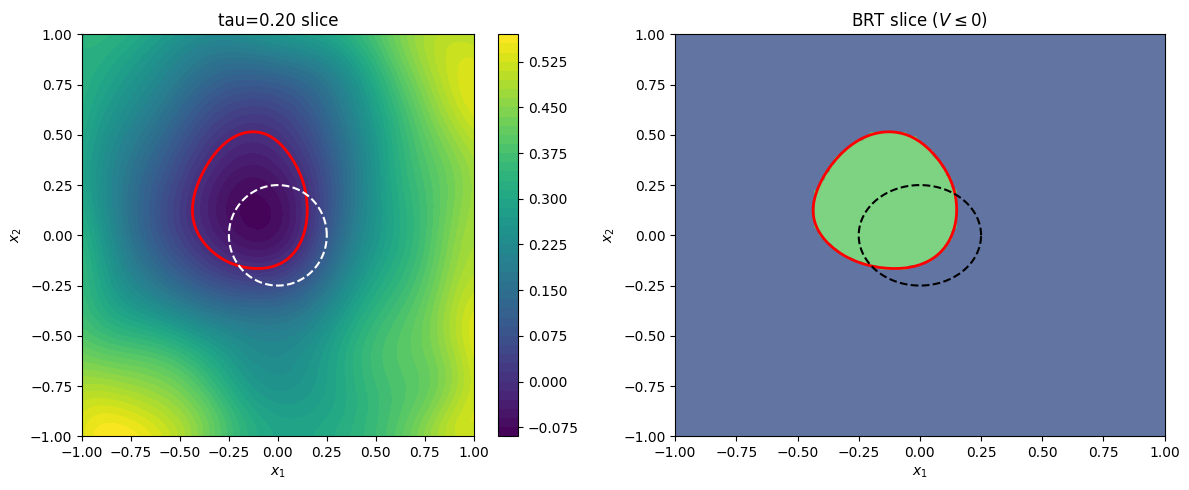


Training with tau_max = 0.40
step    0 | loss=5.968e-02 | term=2.340e-03 | pinn=5.734e-02


In [ ]:
tau_schedule = [0.05, 0.1, 0.2, 0.4, 0.7, 1.0]
steps_per_stage = 400

model.loss_manager.loss_weights = {
    "term": 1.0,
    "pinn": 1.0,
    "ic": 0.0,
    "bc": 0.0,
}

for tau_max in tau_schedule:
    dataset_tr.set_tau_max(tau_max)
    print(f"\nTraining with tau_max = {tau_max:.2f}")

    for step, batch in enumerate(dataloader_tr):
        if step >= steps_per_stage:
            break

        for opt in optimizers.values():
            opt.zero_grad()

        results = model.compute_all_losses(batch, mode="train")
        results["loss_train"].backward()

        torch.nn.utils.clip_grad_norm_(model.decoder.parameters(), max_norm=1.0)
        torch.nn.utils.clip_grad_norm_(model.ode_func_net.parameter s(), max_norm=1.0)

        if "optim_problem" in optimizers:
            problem_params = problem.trainable_parameters()
            if len(problem_params) > 0:
                torch.nn.utils.clip_grad_norm_(problem_params, max_norm=1.0)

        for opt in optimizers.values():
            opt.step() 

        if step % 50 == 0:
            print(
                f"step {step:4d} | "
                f"loss={results['loss_train'].item():.3e} | "
                f"term={results['loss_term'].item():.3e} | "
                f"pinn={results['loss_pinn'].item():.3e}"
            )

    plot_air3d_slice(
        model,
        device=device,
        tau=0.0,
        x3_value=math.pi / 2,
        x1_bounds=args.x1_bounds,
        x2_bounds=args.x2_bounds,
        nx=101,
        chunk_size=2048,
        title=f"tau=0.0 after tau_max={tau_max:.2f}",
    )

    plot_air3d_slice(
        model,
        device=device,
        tau=min(tau_max, args.T),
        x3_value=math.pi / 2,
        x1_bounds=args.x1_bounds,
        x2_bounds=args.x2_bounds,
        nx=101,
        chunk_size=2048,
        title=f"tau={tau_max:.2f} slice",
    )

In [ ]:
plot_air3d(model, device=device, taus=(0.0, 0.5, 1.0), x3_value=math.pi / 2, x1_bounds=args.x1_bounds, x2_bounds=args.x2_bounds, nx=101, chunk_size=2048, mask_plot=True,)